In [155]:
import numpy as np
import pandas as pd
import xgboost as xgb
import missingno as msno
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

**1. Loading datasets**

In [156]:
path = "../gdelt_gold_news_sentiments.csv"
news = pd.read_csv(path)
news = news.rename(columns={"date": "Date"})
news.head()

,Date,text,sentiment
0,2015-12-27,Here's a summary of gold-related news based on...,negative
1,2015-12-28,Several reports discuss gold smuggling attempt...,positive
2,2015-12-29,Several reports discuss gold smuggling attempt...,positive
3,2015-12-30,Here's a summary of gold market news from the ...,positive
4,2015-12-31,Here's a summary of gold market news from the ...,positive


In [157]:
path = "../dataset/modified_financial_data.csv"
stocks = pd.read_csv(path)
stocks.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date
0,2058.199951,114.080002,159.119995,15.11,1.208941,2015-01-02
1,2020.579956,115.800003,150.320007,15.50,1.194643,2015-01-05
2,2002.609985,117.120003,144.399994,15.83,1.193902,2015-01-06
3,2025.900024,116.430000,146.960007,15.85,1.187536,2015-01-07
4,2062.139893,115.940002,148.399994,15.64,1.183600,2015-01-08


**2. Preprocessing**

In [158]:
df = pd.merge(stocks, news, on="Date", how="left")
df.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,text,sentiment
0,2058.199951,114.080002,159.119995,15.11,1.208941,2015-01-02,NaN,NaN
1,2020.579956,115.800003,150.320007,15.50,1.194643,2015-01-05,NaN,NaN
2,2002.609985,117.120003,144.399994,15.83,1.193902,2015-01-06,NaN,NaN
3,2025.900024,116.430000,146.960007,15.85,1.187536,2015-01-07,NaN,NaN
4,2062.139893,115.940002,148.399994,15.64,1.183600,2015-01-08,NaN,NaN


In [159]:
df.isnull().sum()

^GSPC          0
GLD            0
USO            0
SLV            0
EURUSD=X       0
Date           0
text         250
sentiment    250
dtype: int64

<Axes: >

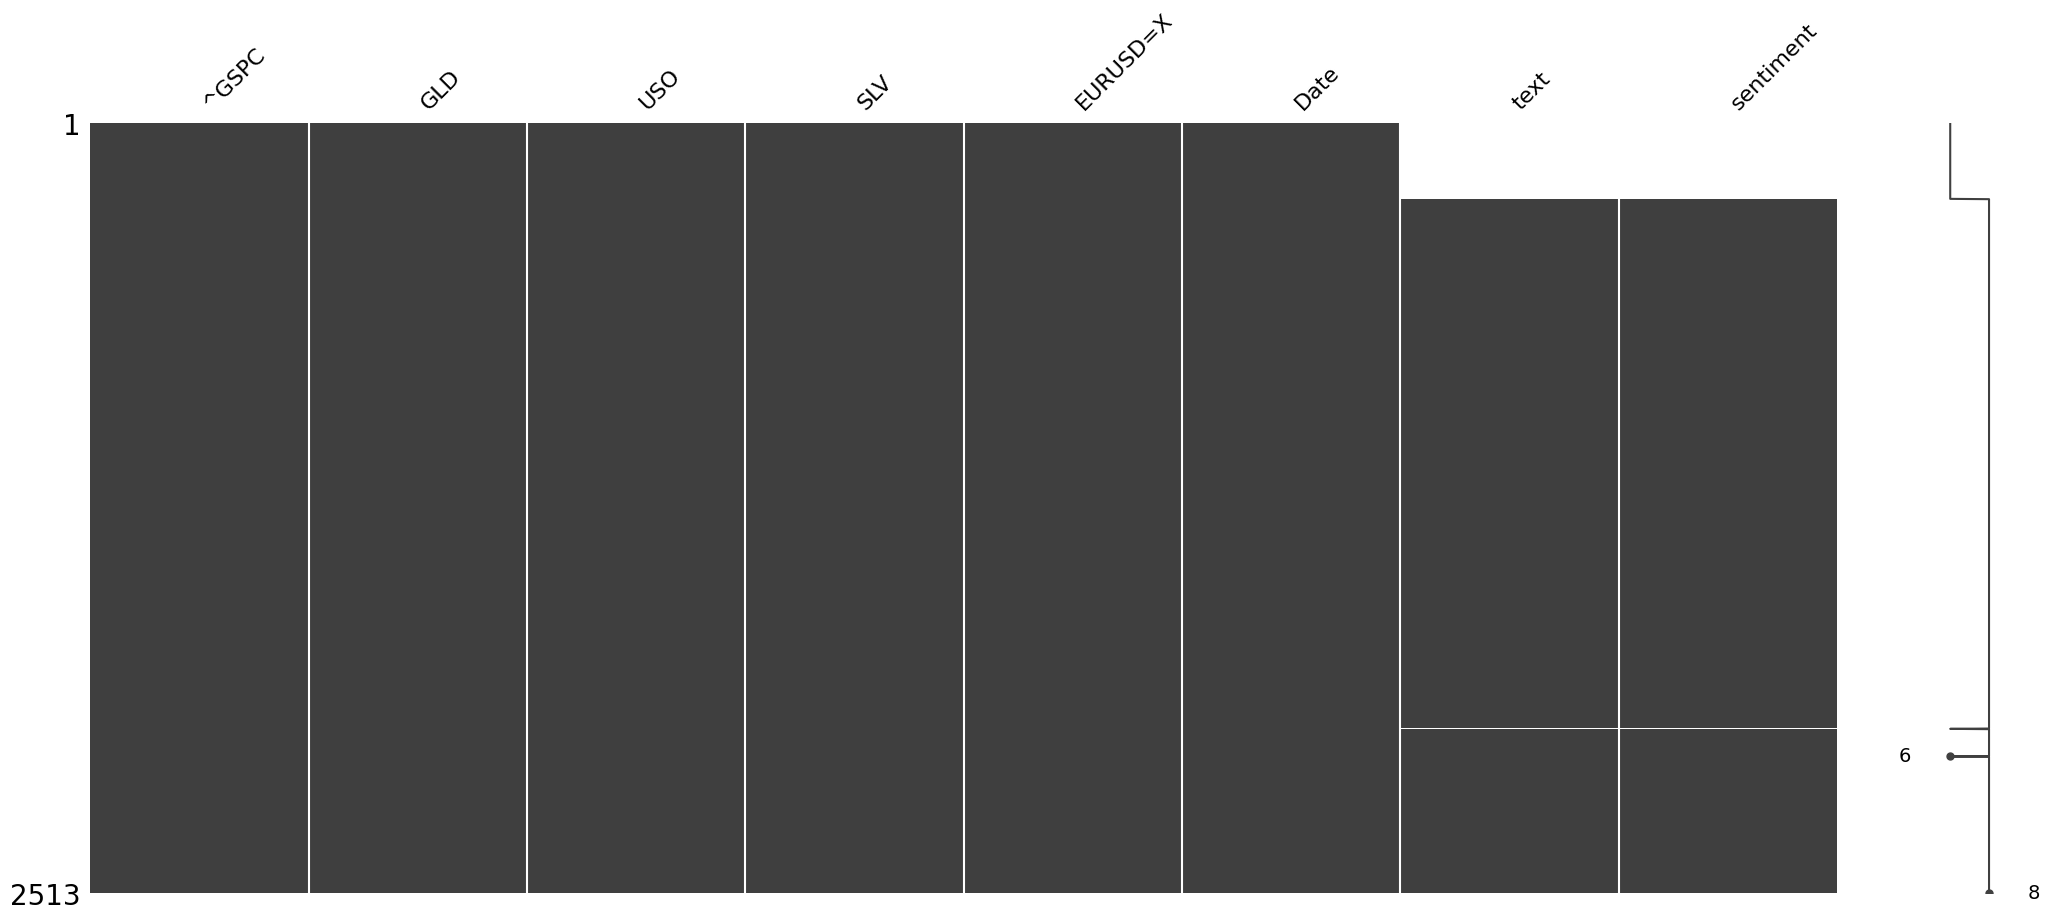

In [160]:
msno.matrix(df)

In [161]:
df = df.dropna()
df.isnull().sum()

^GSPC        0
GLD          0
USO          0
SLV          0
EURUSD=X     0
Date         0
text         0
sentiment    0
dtype: int64

In [162]:
df = df.drop(columns=["text"])
df.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,sentiment
248,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,positive
249,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,positive
250,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,positive
251,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,positive
252,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,positive


In [163]:
lag_cols = ['USO', 'SLV', 'EURUSD=X', '^GSPC', 'sentiment']

for col in lag_cols:
    df[f"{col}_prev"] = df[col].shift(1)

df.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,sentiment,USO_prev,SLV_prev,EURUSD=X_prev,^GSPC_prev,sentiment_prev
248,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,positive,NaN,NaN,NaN,NaN,None
249,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,positive,87.440002,13.29,1.096599,2056.500000,positive
250,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,positive,90.080002,13.27,1.097526,2078.360107,positive
251,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,positive,87.440002,13.21,1.092801,2063.360107,positive
252,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,positive,88.000000,13.19,1.093398,2043.939941,positive


In [164]:
df = df.drop(columns=lag_cols)

In [165]:
df.head()

,GLD,Date,USO_prev,SLV_prev,EURUSD=X_prev,^GSPC_prev,sentiment_prev
248,102.269997,2015-12-28,NaN,NaN,NaN,NaN,None
249,102.199997,2015-12-29,87.440002,13.29,1.096599,2056.500000,positive
250,101.419998,2015-12-30,90.080002,13.27,1.097526,2078.360107,positive
251,101.459999,2015-12-31,87.440002,13.21,1.092801,2063.360107,positive
252,102.889999,2016-01-04,88.000000,13.19,1.093398,2043.939941,positive


In [166]:
df = df.dropna()

In [167]:
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment"] = df["sentiment_prev"].map(sentiment_map)
df.head()

,GLD,Date,USO_prev,SLV_prev,EURUSD=X_prev,^GSPC_prev,sentiment_prev,sentiment
249,102.199997,2015-12-29,87.440002,13.29,1.096599,2056.500000,positive,1
250,101.419998,2015-12-30,90.080002,13.27,1.097526,2078.360107,positive,1
251,101.459999,2015-12-31,87.440002,13.21,1.092801,2063.360107,positive,1
252,102.889999,2016-01-04,88.000000,13.19,1.093398,2043.939941,positive,1
253,103.180000,2016-01-05,87.839996,13.19,1.085399,2012.660034,positive,1


In [168]:
df = df.drop(columns=["sentiment_prev"])

In [169]:
df.columns

Index(['GLD', 'Date', 'USO_prev', 'SLV_prev', 'EURUSD=X_prev', '^GSPC_prev',
       'sentiment'],
      dtype='object')

**3. Random Forest Regressor**

In [170]:
features = ['USO_prev', 'SLV_prev', 'EURUSD=X_prev', '^GSPC_prev', 'sentiment']
target = 'GLD'

split_index = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_index], df.iloc[split_index:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
X_test = scaler_X.transform(test_df[features])

y_train = scaler_y.fit_transform(train_df[[target]])
y_test = scaler_y.transform(test_df[[target]])


In [171]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.ravel())
rf_preds = rf.predict(X_test)

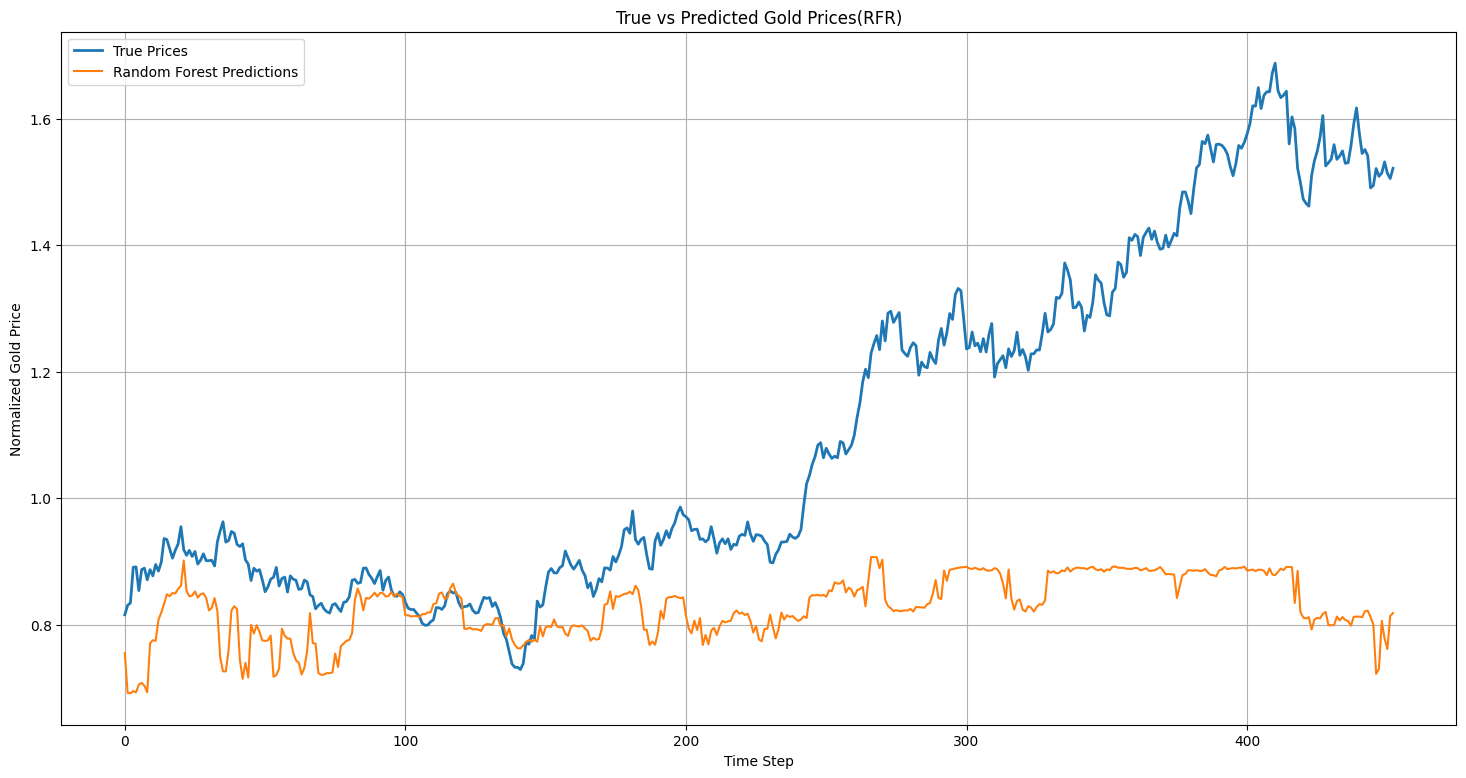

In [172]:
plt.figure(figsize=(18, 9))
plt.plot(y_test, label='True Prices', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predictions')
plt.title('True vs Predicted Gold Prices(RFR)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.show()

**4. LSTM Predictions**

In [173]:
def create_sequences(df_seq, features, target_col, n_steps, scaler_X, scaler_y):
    data_scaled = df_seq.copy()
    X_scaled = scaler_X.transform(data_scaled[features])
    y_scaled = scaler_y.transform(data_scaled[[target_col]])

    X_seq, y_seq = [], []
    for i in range(n_steps, len(data_scaled)):
        X_seq.append(X_scaled[i - n_steps:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq)

In [174]:
n_steps = 10
X_lstm_train, y_lstm_train = create_sequences(train_df, features, target, n_steps, scaler_X, scaler_y)
X_lstm_test, y_lstm_test = create_sequences(test_df, features, target, n_steps, scaler_X, scaler_y)
y_lstm_test_aligned = scaler_y.inverse_transform(y_lstm_test)

rf_preds_aligned = rf_preds[-len(y_lstm_test_aligned):]
y_test_aligned = y_test[-len(y_lstm_test_aligned):]

# x-axis
x_axis = test_df.index[n_steps:] 

model_lstm = Sequential([
    LSTM(50, input_shape=(n_steps, len(features))),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm_train, y_lstm_train, epochs=20, batch_size=16, verbose=0)

lstm_preds = model_lstm.predict(X_lstm_test).ravel()

c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [175]:
min_len = min(len(rf_preds), len(lstm_preds))
rf_preds = rf_preds[-min_len:]
lstm_preds = lstm_preds[-min_len:]
y_true = y_test[-min_len:].ravel()

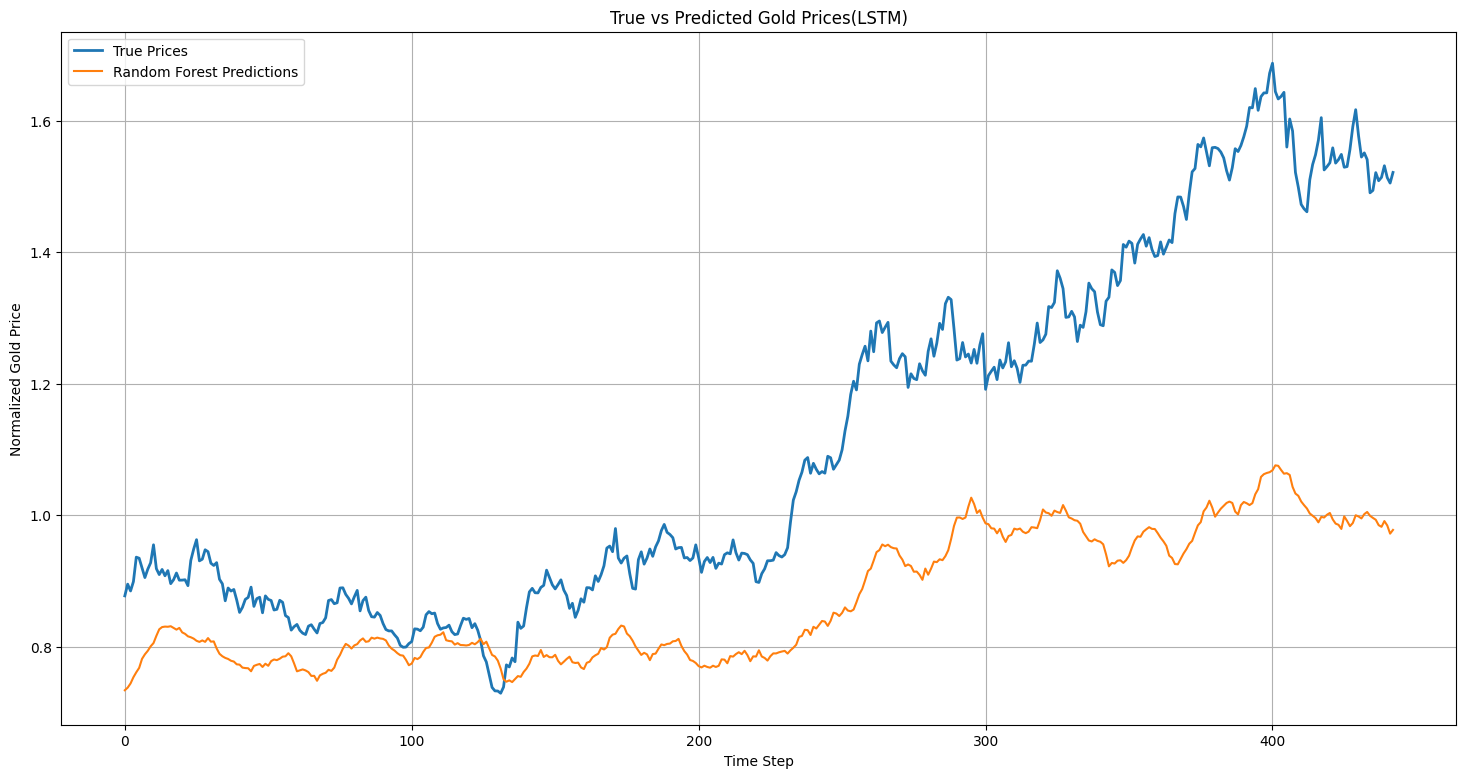

In [176]:
plt.figure(figsize=(18, 9))
plt.plot(y_true, label='True Prices', linewidth=2)
plt.plot(lstm_preds, label='Random Forest Predictions')
plt.title('True vs Predicted Gold Prices(LSTM)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.show()

**5. Stack Ensemble (XGBoost Model)**

In [177]:
lookback = 60
aligned_y_test = y_test[lookback:]
aligned_rf_preds = rf_preds[lookback:]    
aligned_lstm_preds = lstm_preds   

In [178]:
len(rf_preds)

443

In [179]:
len(lstm_preds)

443

In [180]:
len(y_true)

443

In [181]:
meta_df = df = pd.DataFrame({
    "rf_preds": rf_preds,
    "lstm_preds": lstm_preds,
    "y_true": y_true
})

In [182]:
meta_df.head()

,rf_preds,lstm_preds,y_true
0,0.775269,0.733532,0.877149
1,0.774405,0.737498,0.894993
2,0.807930,0.743860,0.884611
3,0.819083,0.753356,0.898886
4,0.832766,0.760890,0.936087


In [183]:
features = ["rf_preds", "lstm_preds"]
target = "y_true"

X = meta_df[features]
y = meta_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.8, shuffle=False)


In [184]:
meta_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

meta_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [185]:
meta_preds = meta_model.predict(X_test)

  Metric     Value
0    MSE  0.127345
1     R² -0.716919
2    MAE  0.278266


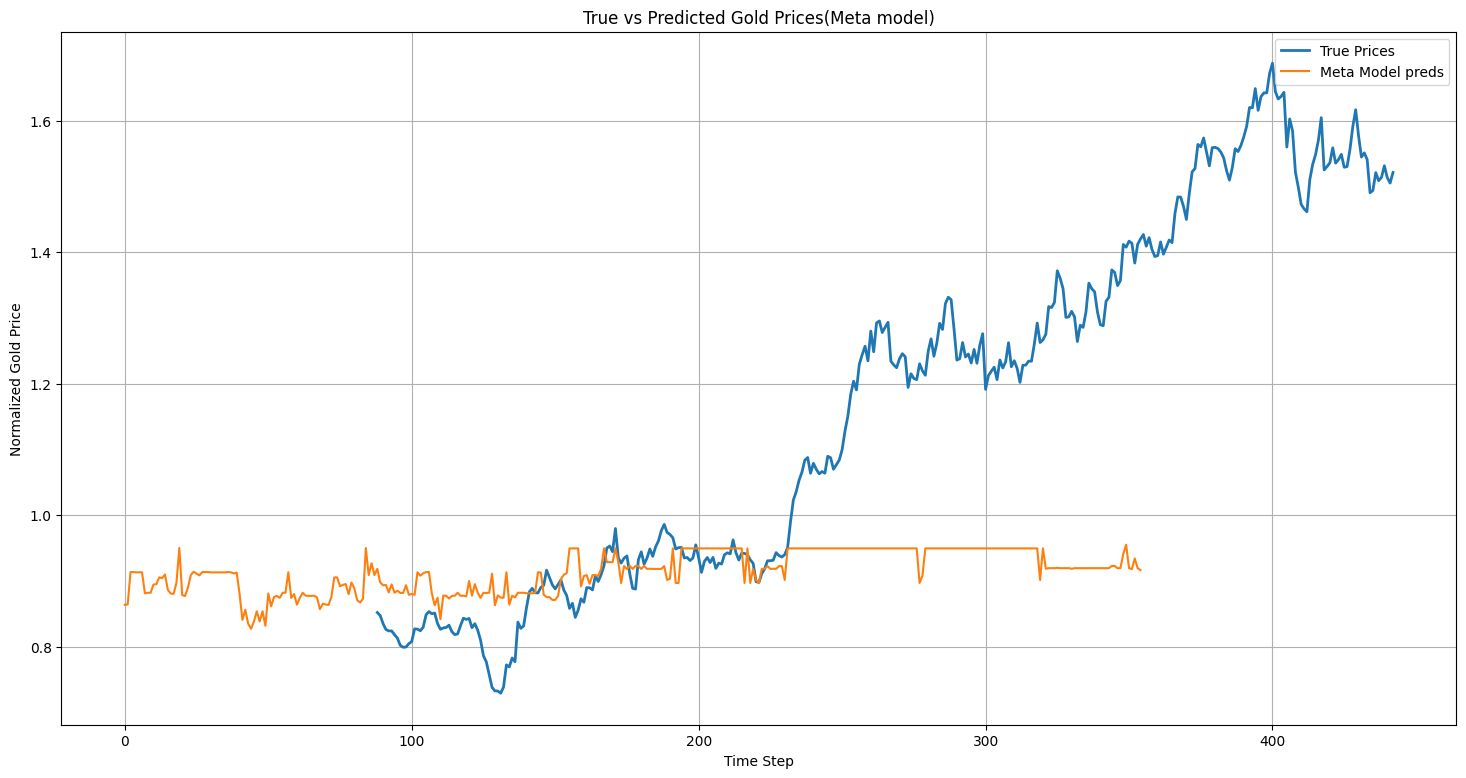

In [186]:
mse = mean_squared_error(y_test, meta_preds)
r2 = r2_score(y_test, meta_preds)
mae = mean_absolute_error(y_test, meta_preds)

results_df = pd.DataFrame({
    "Metric": ["MSE", "R²", "MAE"],
    "Value": [mse, r2, mae]
})
print(results_df)

plt.figure(figsize=(18, 9))
plt.plot(y_test, label='True Prices', linewidth=2)
plt.plot(meta_preds, label='Meta Model preds')
plt.title('True vs Predicted Gold Prices(Meta model)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.show()